**Introduction and Data Summary**

I chose the Heart Failure Prediction Dataset containing various patient health metrics and clinical measurements to build a classification model that can predict the severity of heart disease in a patient

prediction Goal and target Label:the goal is to predict heart disease severity where the target label num represents:
0:No heart disease
1-4:Increasing severity levels of heart disease

Potential Applications:Clinical Decision Support/Early Detection Systems

i wanted to encode the dataset first to make the moodel learn better 

In [244]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
df=pd.read_csv('heart_disease_cleaned.csv')
print("DATA PREPROCESSING WITH ENCODING")
print("======================================================")
df['fbs']=df['fbs'].astype(int)
df['exang']=df['exang'].astype(int)
numerical_features=['age','trestbps','chol','thalch','oldpeak','ca','fbs','exang']
categorical_cols=['sex','dataset','cp','restecg','slope','thal']
encoders={}
for i in categorical_cols:
    en=LabelEncoder()
    df[i]=en.fit_transform(df[i].astype(str))
    encoders[col]=en
all_features=numerical_features + categorical_cols
X=df[all_features]
y=df['num']

DATA PREPROCESSING WITH ENCODING


**Train-Validation-Test Split and Cross-Validation**

In [247]:
print("TRAIN-VALIDATION-TEST SPLIT (70-15-15)")
print("\n============================")
X_temp,X_test,y_temp,y_test=train_test_split(
    X, y,test_size=0.15,random_state=42,stratify=y
)
X_train,X_val,y_train,y_val=train_test_split(
    X_temp,y_temp,test_size=0.176,random_state=42,stratify=y_temp
)
print("\nOriginal distribution (%)")
print(y.value_counts(normalize=True).sort_index())
print("\nTrain distribution (%)")
print(y_train.value_counts(normalize=True).sort_index())
print("\nValidation distribution (%)")
print(y_val.value_counts(normalize=True).sort_index())
print("\nTest distribution (%)")
print(y_test.value_counts(normalize=True).sort_index())
print(f"Train:{X_train.shape[0]} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:{X_val.shape[0]} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:{X_test.shape[0]} samples ({len(X_test)/len(X)*100:.1f}%)")
print("\n============================")
print("SCALING because k-fold needs it ")
print("==========================")
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test)
# 3. K-Fold Cross-Validation
print("\n=======================")
print("K-FOLD CROSS-VALIDATION")
print("=========================")
model=RandomForestClassifier(n_estimators=100,max_depth=10,min_samples_split=20,min_samples_leaf=10,max_features='sqrt',random_state=42)
k_folds=5
skf=StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
cv_scores=cross_val_score(model,X_train_scaled,y_train,cv=skf,scoring='accuracy')
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

TRAIN-VALIDATION-TEST SPLIT (70-15-15)


Original distribution (%)
num
0    0.447225
1    0.288357
2    0.118607
3    0.115343
4    0.030468
Name: proportion, dtype: float64

Train distribution (%)
num
0    0.446345
1    0.287714
2    0.119751
3    0.115086
4    0.031104
Name: proportion, dtype: float64

Validation distribution (%)
num
0    0.449275
1    0.289855
2    0.115942
3    0.115942
4    0.028986
Name: proportion, dtype: float64

Test distribution (%)
num
0    0.449275
1    0.289855
2    0.115942
3    0.115942
4    0.028986
Name: proportion, dtype: float64
Train:643 samples (70.0%)
Val:138 samples (15.0%)
Test:138 samples (15.0%)

SCALING because k-fold needs it 

K-FOLD CROSS-VALIDATION
Mean CV Accuracy: 0.6066 (+/- 0.0877)


**Model Selection and Training**

In [250]:
print("\n1. k-NEAREST NEIGHBORS (k-NN)")
print("-----------------------------------------")
print("Learning Type: Lazy Learning")
print("Description: Stores training data, makes predictions by finding k most similar instances")
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_score=accuracy_score(y_val, knn.predict(X_val_scaled))
print(f"Hyperparameters: n_neighbors=5")
print(f"Validation Accuracy: {knn_score:.4f}")
print("\n2. DECISION TREE")
print("-----------------------------------------")
print("Learning Type: Eager Learning")
print("Description: Learns tree structure by recursively splitting data")
dt=DecisionTreeClassifier(max_depth=10,random_state=42)
dt.fit(X_train_scaled, y_train)
dt_score=accuracy_score(y_val, dt.predict(X_val_scaled))
print("Hyperparameters: max_depth=10,criterion='gini'")
print(f"Validation Accuracy: {dt_score:.4f}")
print("\n3. NEURAL NETWORK (MLPClassifier)")
print("-----------------------------------------")
print("Learning Type: Eager Learning")
print("Description: Uses multiple layers of neurons with activation functions")
print("to learn complex non-linear patterns through backpropagation")
mlp=MLPClassifier(hidden_layer_sizes=(100,50),max_iter=1000,random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_score=accuracy_score(y_val, mlp.predict(X_val_scaled))
print("Hyperparameters: hidden_layer_sizes=(100,50),max_iter=1000")
print(f"Validation Accuracy: {mlp_score:.4f}")
print("\n4. RANDOM FOREST")
print("-----------------------------------------")
print("Learning Type: Eager Learning")
print("Description: Ensemble of decision trees using bagging and")
print("feature randomness to reduce overfitting")
rf=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_score=accuracy_score(y_val,rf.predict(X_val_scaled))
print("Hyperparameters: n_estimators=100, max_depth=10")
print(f"Validation Accuracy: {rf_score:.4f}")


1. k-NEAREST NEIGHBORS (k-NN)
-----------------------------------------
Learning Type: Lazy Learning
Description: Stores training data, makes predictions by finding k most similar instances
Hyperparameters: n_neighbors=5
Validation Accuracy: 0.6522

2. DECISION TREE
-----------------------------------------
Learning Type: Eager Learning
Description: Learns tree structure by recursively splitting data
Hyperparameters: max_depth=10,criterion='gini'
Validation Accuracy: 0.5725

3. NEURAL NETWORK (MLPClassifier)
-----------------------------------------
Learning Type: Eager Learning
Description: Uses multiple layers of neurons with activation functions
to learn complex non-linear patterns through backpropagation
Hyperparameters: hidden_layer_sizes=(100,50),max_iter=1000
Validation Accuracy: 0.5942

4. RANDOM FOREST
-----------------------------------------
Learning Type: Eager Learning
Description: Ensemble of decision trees using bagging and
feature randomness to reduce overfitting
Hyper

**Evaluation Metrics and Class Imbalance**

In [253]:
models={
    'k-NN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=10,random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50),max_iter=1000,random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
}
for name, model in models.items():
    print(f"\n{name}")
    print("-------------------------------------------------------")
    model.fit(X_train_scaled, y_train)
    y_pred=model.predict(X_val_scaled)
    accuracy=accuracy_score(y_val, y_pred)
    precision=precision_score(y_val,y_pred,average='weighted',zero_division=0)
    recall=recall_score(y_val,y_pred,average='weighted',zero_division=0)
    f1=f1_score(y_val, y_pred,average='weighted',zero_division=0)
    f1_macro=f1_score(y_val, y_pred,average='macro',zero_division=0)
    cm=confusion_matrix(y_val, y_pred)
    print(f"Accuracy:{accuracy:.4f}")
    print(f"Precision:{precision:.4f}")
    print(f"Recall:{recall:.4f}")
    print(f"F1-score:{f1:.4f}")
    print(f"F1-macro:{f1_macro:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    zero_division=0
    print(f"\nClassification Report:")
print(classification_report(y_val,y_pred,target_names=['Class 0','Class 1','Class 2','Class 3','Class 4'],zero_division=0))
print("\n=====================================================")
print("WHY ACCURACY ALONE CAN BE MISLEADING")
print("=======================================================")
print("Class Distribution in Validation Set:")
class_counts = dict(sorted(Counter(y_val).items()))
for cls,count in class_counts.items():
    print(f"Class {cls}:{count} samples ({count/len(y_val)*100:.1f}%)")
print("\nKey Issues with Accuracy in Imbalanced Data:")
print("1.Model can achieve high accuracy by only predicting the majority class")
print("2.Critical classes (like severe heart disease) may be ignored")
print("3. 65% accuracy is good but model might miss all severe cases")
print("4.Missing severe heart disease cases has serious consequences")
print("\n=====================================================")
print("F1-SCORE INTERPRETATION")
print("=======================================================")
print("When F1-macro<F1-weighted:model performs poorly on minority classes")
print("When both are similar:balanced performance across all classes")
print("\nF1-Score Comparison:")
f1_comparison = {}
for name, model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_val_scaled)
    f1_weighted=f1_score(y_val, y_pred,average='weighted',zero_division=0)
    f1_macro=f1_score(y_val, y_pred,average='macro',zero_division=0)
    f1_comparison[name]=(f1_weighted,f1_macro)
for name,(f1_w, f1_m) in f1_comparison.items():
    print(f"{name:15}: Weighted F1 ={f1_w:.4f},Macro F1 = {f1_m:.4f}")
    if abs(f1_w-f1_m)>0.08:
        print("Large gap indicates poor performance on minority classes")
    else:
        print("Balanced performance across classes")


k-NN
-------------------------------------------------------
Accuracy:0.6522
Precision:0.6264
Recall:0.6522
F1-score:0.6239
F1-macro:0.4018

Confusion Matrix:
[[55  7  0  0  0]
 [ 7 27  6  0  0]
 [ 3  6  6  1  0]
 [ 1  6  7  2  0]
 [ 1  2  0  1  0]]

Classification Report:

Decision Tree
-------------------------------------------------------
Accuracy:0.5725
Precision:0.5890
Recall:0.5725
F1-score:0.5776
F1-macro:0.3994

Confusion Matrix:
[[48 12  0  2  0]
 [ 6 17  8  7  2]
 [ 1  5  5  5  0]
 [ 0  4  3  9  0]
 [ 1  1  1  1  0]]

Classification Report:

Neural Network
-------------------------------------------------------
Accuracy:0.5942
Precision:0.6069
Recall:0.5942
F1-score:0.5975
F1-macro:0.4225

Confusion Matrix:
[[48 12  1  1  0]
 [ 6 20  5  7  2]
 [ 4  2  5  4  1]
 [ 0  5  1  9  1]
 [ 0  2  0  2  0]]

Classification Report:

Random Forest
-------------------------------------------------------
Accuracy:0.6522
Precision:0.6402
Recall:0.6522
F1-score:0.6454
F1-macro:0.4479

Confu

**why accuracy alone may be misleading in imbalanced data**

when working with imbalanced datasets where some classes have many more examples than others accuracy can give us a false sense of how good our model really is
in my dataset the classes are uneven

Class 0 (No disease):44.9% of patients
Class 1 (Mild):29.0% of patients
Class 2 (Moderate):11.6% of patients
Class 3 (Severe):11.6% of patients
Class 4 (Critical):2.9% of patients

a model could cheat by always predicting the most common class (Class 0) this lazy model would be correct 44.9% of the time without learning anything about heart disease patterns
k-NN and Random Forest:65.2% accuracy but they detected 0% of critical heart disease cases (Class 4)

**Overfitting and Model Comparison** 

**Plot training vs.validation accuracy**

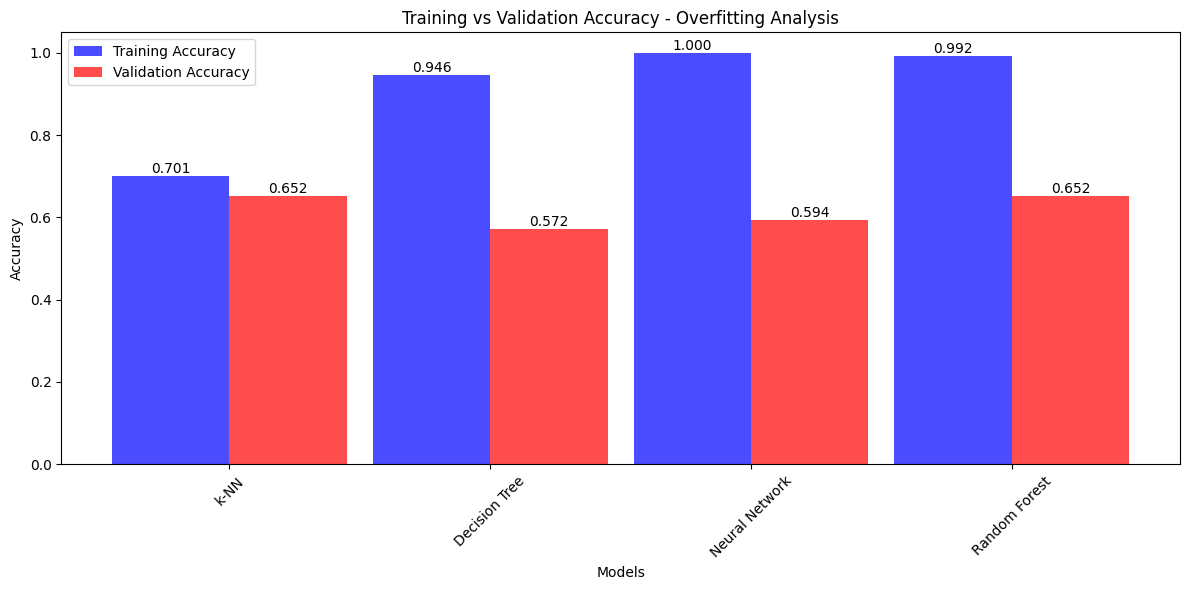

In [259]:
train_accuracies={}
val_accuracies={}
for name,model in models.items():
    model.fit(X_train_scaled, y_train)
    train_acc=accuracy_score(y_train,model.predict(X_train_scaled))
    val_acc=accuracy_score(y_val,model.predict(X_val_scaled))
    train_accuracies[name]=train_acc
    val_accuracies[name]=val_acc
models_list=list(models.keys())
train_accs=[train_accuracies[name] for name in models_list]
val_accs=[val_accuracies[name] for name in models_list]
x=np.arange(len(models_list))
width=0.45
fig,ax=plt.subplots(figsize=(12, 6))
bars1=ax.bar(x-width/2,train_accs,width,label='Training Accuracy',color='blue',alpha=0.7)
bars2=ax.bar(x+width/2,val_accs,width,label='Validation Accuracy',color='red',alpha=0.7)
ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Validation Accuracy - Overfitting Analysis')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=45)
ax.legend()
for bar in bars1+bars2:
    height=bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2.,height,f'{height:.3f}',ha='center',va='bottom')
plt.tight_layout()
plt.show()

**Signs of Overfitting in my Models**
All models show 0% recall for Class 4 /Large gap between weighted F1 and macro F1
Models work well for common cases but fail for important cases

Cross-validation accuracy: 0.6066 ± 0.0877/Large standard deviation suggests models aren't stable
Performance varies a lot between different data splits

Lowest validation accuracy (57.25%) despite being capable of complex rules/Single tree with max_depth=10 likely memorized training data/Creates overly specific rules that don't generalize

Simple k-NN performs as well as complex Neural Network/Suggests complex models might be learning noise instead of patterns/Random Forest performs best because it reduces overfitting through averaging



**Methods to Reduce Overfitting**:

Cross-Validation:Instead of one train/test split use 5 different splits 

Pruning(For Decision Trees):Remove rules that are too specific to training data

For Neural Networks:adds penalty for large weights/for k-NN: Increase k value Use distanc weighted voting

Focus on:max_depth,min_samples,k-value,regularization strength
(i tried this and infact i got better results)
i did encode the catogories cols and i got better results than when i didn't encode (but 
still no model get the class 4 correctly)

**Feature Importance (Random Forest)**

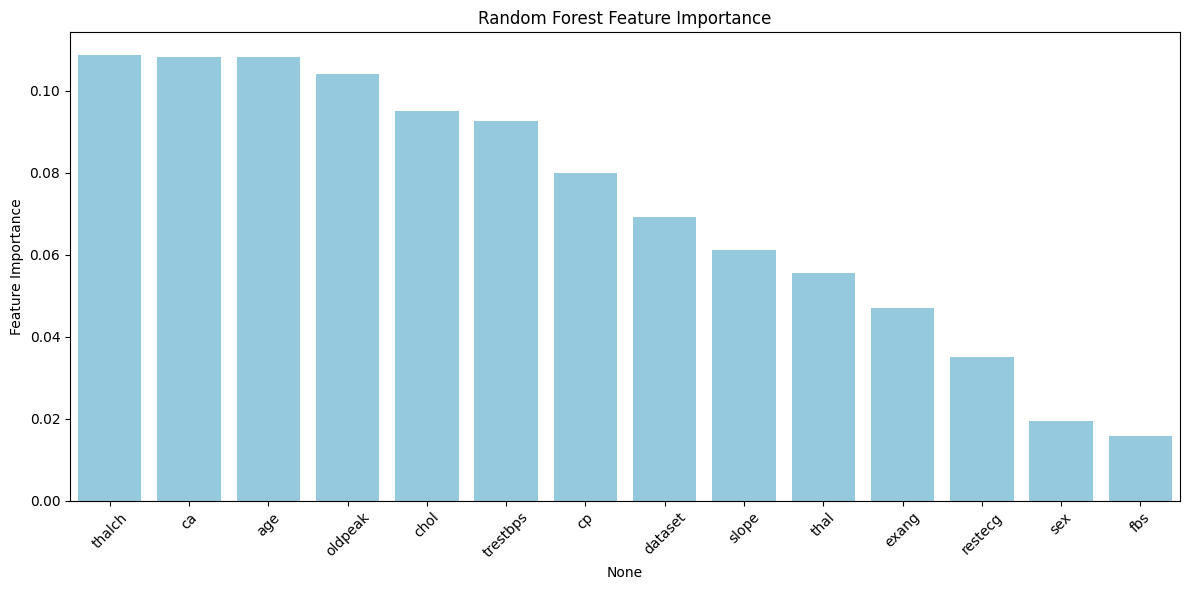

In [224]:
rf_importances=rf.feature_importances_
feature_names=X.columns
indices=np.argsort(rf_importances)[::-1]
sorted_features=feature_names[indices]
sorted_importances=rf_importances[indices]
plt.figure(figsize=(12,6))
sns.barplot(x=sorted_features,y=sorted_importances,color="skyblue")
plt.xticks(rotation=45)
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

**Confusion Matrices for All Models**

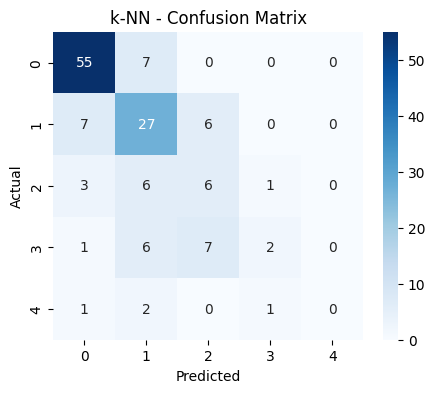

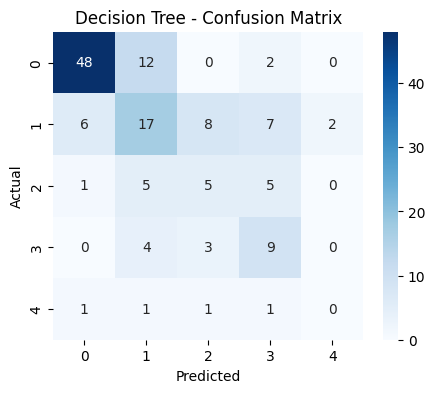

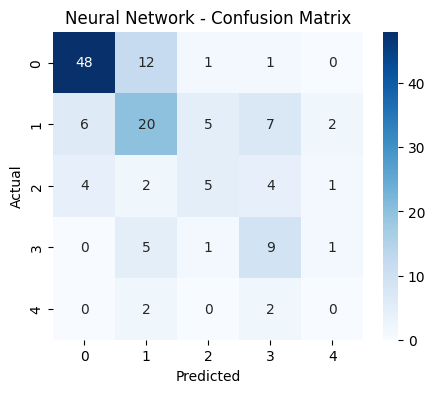

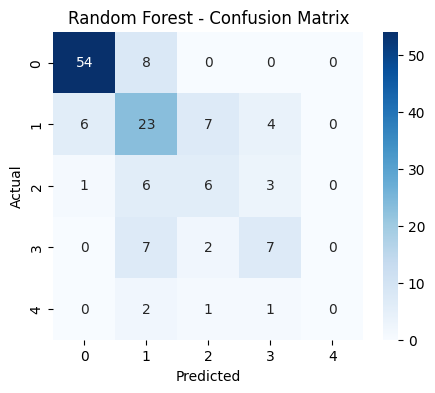

In [228]:
from sklearn.metrics import classification_report
for name,model in models.items():
    y_pred=model.predict(X_val_scaled)
    cm=confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


**Summarize what the models learned about the data**

I ran several machine learning models on a heart disease dataset to classify severity from 0 (no disease) to 4 (severe disease)

the first thing i noticed is that the data isn't balanced Almost 45% of the patients are in Class 0 (no heart disease) while only about 3% are in Class 4 (the most severe) this caused a huge problem for all the models

A model could just guess "Class 0" every time and still be almost 45% accurate without learning anything useful tis makes the accuracy scores kinda misleading
 This is the biggest issue all the models completely failed to correctly identify even a single patient in Class 4 in a real-world scenario this is terrible missing the sickest patients is the worst possible mistake

**k-Nearest Neighbors (k-NN):** it was the least overfit meaning what it learned from the training data actually worked okay on new data this suggests there are meaningful patterns in the data but they aren't super complex

**Decision Tree and Neural Network:** these models basically memorized the training set the Neural Network got a perfect 100% score on the training data it showed me that the training data had patterns you could memorize but those patterns didn't generalize when faced with new patients their performance dropped a lot

**Random Forest:** by combining many decision trees it learned the most robust patterns and was the best overall especially at telling Class 0 apart from the rest It was the best model but it still struggled with the same core issues:telling the difference between intermediate classes (1, 2, 3) and completely failing on Class 4

**Summary of Findings**

**Which classifier performed best and why?**
the Random Forest was the best overall classifier it got the highest score on the validation set (about 65% accuracy) and had the best balance across other important metrics like the F1-score it worked well because it uses a whole bunch of decision trees together and each one votes on the answer this team approach helped it avoid memorizing the training data too much (overfitting) which is what messed up the single Decision Tree and the Neural Network it was smarter than the simple k-NN model because it could find more complex patterns in the data

**What trade-offs were observed between accuracy and interpretability?**
the easier a model is to understand the worse it performed

i talked alot about failing on Class 4 but the most damning pattern is in class 3 look at the random forest matrix:for the 16 actual Class 3 patients it misclassified 9 of them and of those 9 mistakes 7 were predicted as Class 1 it's not just confusing Class 3 with its neighbor(class 2) it's frequently sending severe cases all the way back to a much milder category this isn't a small error it means the model's understanding of the disease spectrum is completely broken in the middle it sees a sick patient and often thinks it's not sick 

the Decision Tree is very easy to understand—you can follow its logic like a simple flow chart but it was one of the worstperforming models because it basically memorized the training data on the other hand the Random Forest was more accurate but it's impossible to see a reason for its decisions so we had to choose a less accurate model we can understand or a more accurate one we can

**What features contributed most to prediction performance?** 
 no single feature was a strong predictor 
the importance scores for all features were very low and similar it had to rely on a complex combination of many weak signals from all the features
this is precisely why the Random Forest succeeded it's specially designed to find these subtle combined patterns that simpler models like k-NN or a single Decision Tree would miss

